Lab06 A1: Entropy of Label: 1.5849474223734452
Lab06 A2: Gini index of Label: 0.6666596915646801
Lab06 A3: Best root feature by IG: MFCC3 IG: 0.41358513426212706
Lab06 A4: Equal-width bin edges for MFCC1 : [ 412.48636   583.382645  754.27893   925.175215 1096.0715  ]


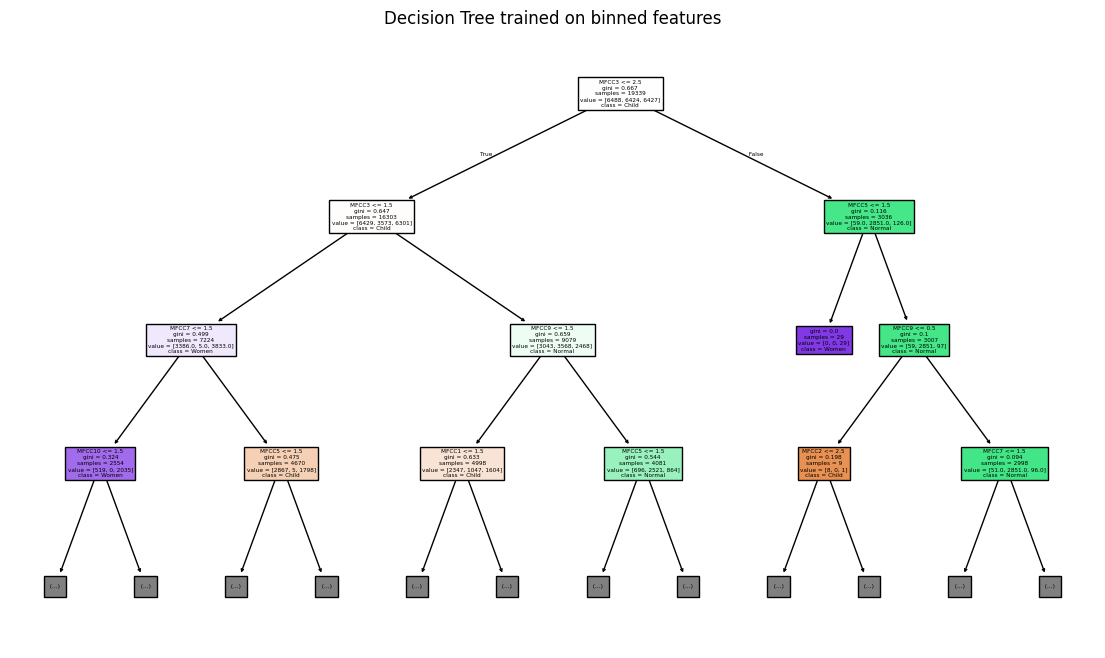

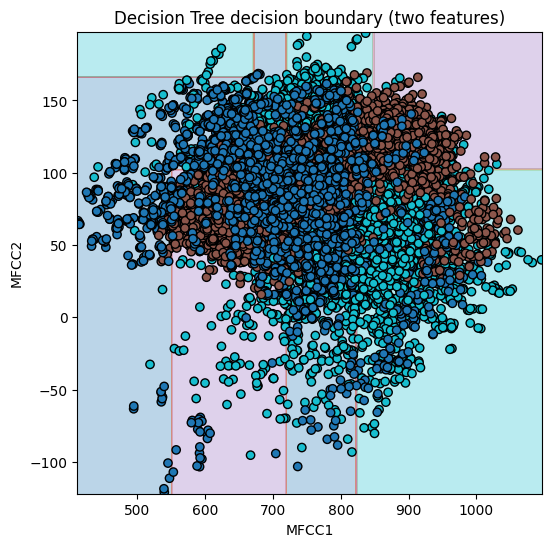

In [3]:
# Lab06_all_questions_corrected.py
import numpy as np
import pandas as pd
from collections import Counter
import math
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict, Any

def load_data(path="/mnt/data/extracted_audio_features.csv"):
    df = pd.read_csv('/Users/dhrithijuvva/Desktop/Women_ML/extracted_audio_features.csv')
    feature_cols = [c for c in df.columns if c.startswith("MFCC")]
    return df, feature_cols

# ---------- A1 entropy ----------
def entropy_of_labels(y):
    y = np.asarray(y)
    n = len(y)
    counts = Counter(y)
    ent = 0.0
    for k, v in counts.items():
        p = v / n
        if p > 0:
            ent -= p * math.log2(p)
    return ent

# ---------- A2 gini ----------
def gini_of_labels(y):
    y = np.asarray(y)
    n = len(y)
    counts = Counter(y)
    g = 1.0
    for v in counts.values():
        p = v / n
        g -= p**2
    return g

# ---------- A4 binning ----------
def equal_width_binning(arr: np.ndarray, bins: int = 4):
    arr = np.asarray(arr)
    minv, maxv = np.nanmin(arr), np.nanmax(arr)
    edges = np.linspace(minv, maxv, bins+1)
    binned = np.digitize(arr, edges[1:-1], right=False)  # values 0..bins-1
    return binned, edges

def equal_frequency_binning(arr: np.ndarray, bins: int = 4):
    arr = np.asarray(arr)
    quantiles = np.nanpercentile(arr, np.linspace(0,100,bins+1))
    edges = np.unique(quantiles)
    if len(edges) < bins+1:  # fallback if not enough unique values
        return equal_width_binning(arr, bins)
    binned = np.digitize(arr, edges[1:-1], right=False)
    return binned, edges

# ---------- A3/A5: Information gain ----------
def information_gain_for_feature(X_feature: np.ndarray, y, base_entropy=None, binning='equal_width', bins=4):
    if binning == 'equal_width':
        binned, _ = equal_width_binning(X_feature, bins=bins)
    else:
        binned, _ = equal_frequency_binning(X_feature, bins=bins)
    n = len(y)
    if base_entropy is None:
        base_entropy = entropy_of_labels(y)
    cond_ent = 0.0
    for val in np.unique(binned):
        idx = np.where(binned == val)[0]
        subset_y = np.array(y)[idx]
        ent_sub = entropy_of_labels(subset_y)
        cond_ent += (len(idx)/n) * ent_sub
    ig = base_entropy - cond_ent
    return ig, binned

def select_root_feature_by_ig(X: np.ndarray, feature_names: List[str], y, binning='equal_width', bins=4):
    base_ent = entropy_of_labels(y)
    best_feat = None
    best_ig = -np.inf
    best_binned = None
    for i, fname in enumerate(feature_names):
        ig, binned = information_gain_for_feature(X[:,i], y, base_entropy=base_ent, binning=binning, bins=bins)
        if ig > best_ig:
            best_ig = ig
            best_feat = fname
            best_binned = binned
    return {"best_feature": best_feat, "best_ig": best_ig, "best_binned": best_binned}

# ---------- A5: Decision tree on binned data ----------
def build_and_plot_decision_tree_binned(df, feature_cols, y_col="Label", binning='equal_width', bins=4, max_depth=4):
    X = df[feature_cols].values
    y = df[y_col].values
    # bin all features
    Xb = np.zeros_like(X, dtype=int)
    edges_list = []
    for i in range(X.shape[1]):
        if binning == 'equal_width':
            binned, edges = equal_width_binning(X[:,i], bins=bins)
        else:
            binned, edges = equal_frequency_binning(X[:,i], bins=bins)
        Xb[:,i] = binned
        edges_list.append(edges)
    # encode labels for training
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    clf = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    clf.fit(Xb, y_enc)
    plt.figure(figsize=(14,8))
    plot_tree(clf, feature_names=feature_cols, class_names=le.classes_, filled=True, max_depth=3)
    plt.title("Decision Tree trained on binned features")
    plt.show()
    return clf, edges_list, le

# ---------- A7: decision boundary for two features ----------
def visualize_decision_boundary_two_features(df, feat1, feat2, y_col="Label", max_depth=4):
    X = df[[feat1, feat2]].values
    y = df[y_col].values
    # encode labels
    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    clf = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    clf.fit(X, y_enc)

    # mesh
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = clf.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(6,6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="tab10")
    plt.scatter(X[:,0], X[:,1], c=y_enc, edgecolor='k', cmap="tab10")
    plt.xlabel(feat1)
    plt.ylabel(feat2)
    plt.title("Decision Tree decision boundary (two features)")
    plt.show()
    return clf, le

# ---------- Main ----------
if __name__ == "__main__":
    df, feature_cols = load_data()
    # A1 entropy
    ent = entropy_of_labels(df["Label"].values)
    print("Lab06 A1: Entropy of Label:", ent)
    # A2 gini
    gini = gini_of_labels(df["Label"].values)
    print("Lab06 A2: Gini index of Label:", gini)
    # A3 root feature
    X = df[feature_cols].values
    sel = select_root_feature_by_ig(X, feature_cols, df["Label"].values, binning='equal_width', bins=4)
    print("Lab06 A3: Best root feature by IG:", sel["best_feature"], "IG:", sel["best_ig"])
    # A4 binning example
    binned_sample, edges = equal_width_binning(df[feature_cols[0]].values, bins=4)
    print("Lab06 A4: Equal-width bin edges for", feature_cols[0], ":", edges)
    # A5 build tree on binned
    clf_binned, edges_list, le = build_and_plot_decision_tree_binned(df, feature_cols, y_col="Label", binning='equal_width', bins=4, max_depth=5)
    # A7 decision boundary
    clf2, le2 = visualize_decision_boundary_two_features(df, feature_cols[0], feature_cols[1], y_col="Label", max_depth=4)
